y_MCID shape: (956, 1)


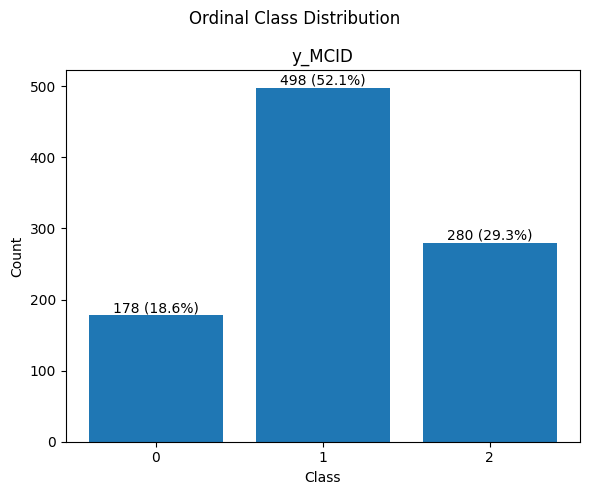

In [30]:
import pandas as pd
import json
import numpy as np
from pathlib import Path

current_dir = Path.cwd()
project_root = current_dir.parents[3]

import matplotlib.pyplot as plt


y_MCID_v2 = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/V2_version/y_MCID_v2_final.csv", index_col=0)
print("y_MCID shape:", y_MCID_v2.shape)



datasets = {
    "y_MCID": y_MCID_v2,
}

fig, ax = plt.subplots(figsize=(6, 5))

df = y_MCID_v2

counts = df.iloc[:,0].value_counts().sort_index()
percentages = counts / counts.sum() * 100

bars = ax.bar(counts.index.astype(str), counts.values)

# añadir texto con conteo y porcentaje
for i, (count, pct) in enumerate(zip(counts.values, percentages.values)):
    ax.text(i, count, f"{count} ({pct:.1f}%)", 
            ha='center', va='bottom')

ax.set_title("y_MCID")
ax.set_xlabel("Class")
ax.set_ylabel("Count")

plt.suptitle("Ordinal Class Distribution")
plt.tight_layout()
plt.show()

# FILES

In [31]:
import os
import re

with open(project_root/"SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/Domain_data.json", "r") as archivo:
    full_domain = json.load(archivo)

with open(project_root/"SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/UPDRS_Domain_data.json", "r") as archivo:
    updrs_domain = json.load(archivo)

X_multiples_MCID= {'X_STATS_V2':project_root/'SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/V2_version/X_stats_v2_final_HY3.csv',
                'X_VX_STATS_V2': project_root/'SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/V2_version/X_vx_stats_v2_final_HY3.csv',
                'X_VX_DELTA_V2': project_root/'SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/V2_version/X_vx_delta_v2_final_HY3.csv',
                }
y_multiples_MCID = {'MCID_v2': project_root / "SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/V2_version/y_MCID_v2_final.csv"}

pairs_init_MCID=[('X_STATS_V2', 'MCID_v2'),
        ('X_VX_STATS_V2', 'MCID_v2'),
        ('X_VX_DELTA_V2', 'MCID_v2')]


output_path= project_root / "SCRIPTS/PYTHON/MODEL_ANALYSIS/Performance_Results/Multiclass/V2_analysis/"

# MODELS BASELINE

In [32]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from imblearn.pipeline import Pipeline


# 🔹 pesos a probar
weight_configs_MCID = {
    "balanced": "balanced",
    "w_c2_10": {0: 10, 1: 1, 2: 10},
    "w_c2_20": {0: 20, 1: 1, 2: 20},
}

def build_models(class_weight):
    return {
        "decision_tree": Pipeline([
            ("model", DecisionTreeClassifier(
                random_state=42,
                class_weight=class_weight
            ))
        ]),

        "random_forest": Pipeline([
            ("model", RandomForestClassifier(
                random_state=42,
                n_jobs=-1,
                class_weight=class_weight
            ))
        ]),

        "extra_trees": Pipeline([
            ("model", ExtraTreesClassifier(
                random_state=42,
                n_jobs=-1,
                class_weight=class_weight
            ))
        ]),

        "xgboost": Pipeline([
            ("model", XGBClassifier(
                tree_method="hist",
                device="cuda",
                eval_metric="logloss",
                n_jobs=-1,
                random_state=42))
        ]),

        "adaboost": Pipeline([
            ("model", AdaBoostClassifier(
                algorithm="SAMME",
                random_state=42
            ))
        ]),

        "svm": Pipeline([
            ("model", SVC(
                kernel="rbf",
                probability=True,
                random_state=42,
                class_weight=class_weight
            ))
        ]),

        "logistic_regression": Pipeline([
            ("model", LogisticRegression(
                random_state=42,
                n_jobs=-1,
                max_iter=10000,
                class_weight=class_weight
            ))
        ]),

        "knn": Pipeline([
            ("model", KNeighborsClassifier(n_jobs=-1))
        ]),

        "gaussian_nb": Pipeline([
            ("model", GaussianNB())
        ]),

        "mlp3216": Pipeline([
            ("model", MLPClassifier(
                hidden_layer_sizes=(32, 16),
                activation='relu',
                solver='adam',
                alpha=0.0001,
                learning_rate='adaptive',
                max_iter=1000,
                random_state=42
            ))
        ])
    }


# ESTRUCTURA FINAL: un dict por weight
classification_models_by_weight_MCID = {
    w_name: build_models(w_value)
    for w_name, w_value in weight_configs_MCID.items()
}



In [33]:

def build_models_reg(class_weight):

    return {
        "decision_tree_reg": Pipeline([
            ("model", DecisionTreeClassifier(
                random_state=42,
                class_weight=class_weight,
                max_depth=3,
                min_samples_split=40,
                min_samples_leaf=15,
                max_features="sqrt",
                ccp_alpha=0.005
            ))
        ]),

        "random_forest_reg": Pipeline([
            ("model", RandomForestClassifier(
                random_state=42,
                n_jobs=-1,
                class_weight=class_weight,
                n_estimators=160,
                max_depth=4,
                min_samples_split=30,
                min_samples_leaf=12,
                max_features="sqrt",
                max_samples=0.80,
                bootstrap=True
            ))
        ]),

        "extra_trees_reg": Pipeline([
            ("model", ExtraTreesClassifier(
                random_state=42,
                n_jobs=-1,
                class_weight=class_weight,
                n_estimators=160,
                max_depth=4,
                min_samples_split=30,
                min_samples_leaf=12,
                max_features="sqrt",
                max_samples=0.80,
                bootstrap=True
            ))
        ]),

        "xgboost_reg": Pipeline([
            ("model", XGBClassifier(
                tree_method="hist",
                device="cuda",
                eval_metric="logloss",
                n_jobs=-1,
                random_state=42,
                n_estimators=120,
                learning_rate=0.04,
                max_depth=4,
                min_child_weight=10,
                gamma=2.0,
                subsample=0.80,
                colsample_bytree=0.80,
                reg_alpha=4.0,
                reg_lambda=12.0
            ))
        ]),

        "adaboost_reg": Pipeline([
            ("model", AdaBoostClassifier(
                n_estimators=60,
                learning_rate=0.04,
                algorithm="SAMME",
                random_state=42
            ))
        ]),

        "svm_reg": Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC(
                kernel="rbf",
                C=0.15,
                gamma="scale",
                probability=True,
                random_state=42,
                class_weight=class_weight
            ))
        ]),

        "logistic_regression_reg": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                random_state=42,
                max_iter=10000,
                C=0.08,
                penalty="l2",
                solver="liblinear",
                class_weight=class_weight
            ))
        ]),

        "knn_reg": Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier(
                n_neighbors=25,
                weights="distance",
                p=2,
                n_jobs=-1
            ))
        ]),

        "gaussian_nb_reg": Pipeline([
            ("model", GaussianNB(
                var_smoothing=1e-6
            ))
        ]),

        "mlp3216_reg": Pipeline([
            ("scaler", StandardScaler()),
            ("model", MLPClassifier(
                hidden_layer_sizes=(10,),
                activation="relu",
                solver="adam",
                alpha=0.05,
                learning_rate="adaptive",
                early_stopping=True,
                validation_fraction=0.20,
                n_iter_no_change=20,
                max_iter=400,
                random_state=42
            ))
        ])
    }


classification_models_by_weight_reg_MCID = {
    w_name: build_models_reg(w_value)
    for w_name, w_value in weight_configs_MCID.items()
}


In [34]:
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

from xgboost import XGBClassifier


def build_models_reg_UNDER(class_weight):
    return {
        "decision_tree_reg": Pipeline([
            ("undersample", RandomUnderSampler(sampling_strategy="auto", random_state=42)),
            ("model", DecisionTreeClassifier(
                random_state=42,
                class_weight=class_weight,
                max_depth=3,
                min_samples_split=40,
                min_samples_leaf=15,
                max_features="sqrt",
                ccp_alpha=0.005
            ))
        ]),

        "random_forest_reg": Pipeline([
            ("undersample", RandomUnderSampler(sampling_strategy="auto", random_state=42)),
            ("model", RandomForestClassifier(
                random_state=42,
                n_jobs=-1,
                class_weight=class_weight,
                n_estimators=160,
                max_depth=4,
                min_samples_split=30,
                min_samples_leaf=12,
                max_features="sqrt",
                max_samples=0.80,
                bootstrap=True
            ))
        ]),

        "extra_trees_reg": Pipeline([
            ("undersample", RandomUnderSampler(sampling_strategy="auto", random_state=42)),
            ("model", ExtraTreesClassifier(
                random_state=42,
                n_jobs=-1,
                class_weight=class_weight,
                n_estimators=160,
                max_depth=4,
                min_samples_split=30,
                min_samples_leaf=12,
                max_features="sqrt",
                max_samples=0.80,
                bootstrap=True
            ))
        ]),

        "xgboost_reg": Pipeline([
            ("undersample", RandomUnderSampler(sampling_strategy="auto", random_state=42)),
            ("model", XGBClassifier(
                tree_method="hist",
                device="cuda",
                eval_metric="logloss",
                n_jobs=-1,
                random_state=42,
                n_estimators=120,
                learning_rate=0.04,
                max_depth=4,
                min_child_weight=10,
                gamma=2.0,
                subsample=0.80,
                colsample_bytree=0.80,
                reg_alpha=4.0,
                reg_lambda=12.0
            ))
        ]),

        "adaboost_reg": Pipeline([
            ("undersample", RandomUnderSampler(sampling_strategy="auto", random_state=42)),
            ("model", AdaBoostClassifier(
                n_estimators=60,
                learning_rate=0.04,
                algorithm="SAMME",
                random_state=42
            ))
        ]),

        "svm_reg": Pipeline([
            ("undersample", RandomUnderSampler(sampling_strategy="auto", random_state=42)),
            ("scaler", StandardScaler()),
            ("model", SVC(
                kernel="rbf",
                C=0.15,
                gamma="scale",
                probability=True,
                random_state=42,
                class_weight=class_weight
            ))
        ]),

        "logistic_regression_reg": Pipeline([
            ("undersample", RandomUnderSampler(sampling_strategy="auto", random_state=42)),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                random_state=42,
                max_iter=10000,
                C=0.08,
                penalty="l2",
                solver="liblinear",
                class_weight=class_weight
            ))
        ]),

        "knn_reg": Pipeline([
            ("undersample", RandomUnderSampler(sampling_strategy="auto", random_state=42)),
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier(
                n_neighbors=25,
                weights="distance",
                p=2,
                n_jobs=-1
            ))
        ]),

        "gaussian_nb_reg": Pipeline([
            ("undersample", RandomUnderSampler(sampling_strategy="auto", random_state=42)),
            ("model", GaussianNB(
                var_smoothing=1e-6
            ))
        ]),

        "mlp3216_reg": Pipeline([
            ("undersample", RandomUnderSampler(sampling_strategy="auto", random_state=42)),
            ("scaler", StandardScaler()),
            ("model", MLPClassifier(
                hidden_layer_sizes=(10,),
                activation="relu",
                solver="adam",
                alpha=0.05,
                learning_rate="adaptive",
                early_stopping=True,
                validation_fraction=0.20,
                n_iter_no_change=20,
                max_iter=400,
                random_state=42
            ))
        ])
    }


classification_models_by_weight_reg_UNDER_MCID = {
    w_name: build_models_reg_UNDER(w_value)
    for w_name, w_value in weight_configs_MCID.items()
}

# MODEL PERFORMANCE FUNCTION

In [35]:
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    precision_score,
    roc_auc_score,
    precision_recall_fscore_support,
    average_precision_score,
    confusion_matrix,
)
from sklearn.preprocessing import label_binarize, LabelEncoder

from imblearn.over_sampling import RandomOverSampler, SMOTE

from sdv.metadata import Metadata
from sdv.single_table import CTGANSynthesizer


def _compute_metrics_multiclass(
    y_true,
    y_pred,
    y_proba=None,
    classes=None,
    cost_matrix=None
):
    metrics = {}

    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    if classes is None:
        classes = np.unique(np.concatenate([y_true, y_pred]))
    classes = np.asarray(classes)

    n_classes = len(classes)

    metrics["accuracy"] = accuracy_score(y_true, y_pred)

    metrics["f1_macro"] = f1_score(y_true, y_pred, average="macro", zero_division=0)
    metrics["f1_weighted"] = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    metrics["recall_macro"] = recall_score(y_true, y_pred, average="macro", zero_division=0)
    metrics["recall_weighted"] = recall_score(y_true, y_pred, average="weighted", zero_division=0)

    metrics["precision_macro"] = precision_score(y_true, y_pred, average="macro", zero_division=0)
    metrics["precision_weighted"] = precision_score(y_true, y_pred, average="weighted", zero_division=0)

    # =========================================================
    # COST MATRIX
    # =========================================================
    if cost_matrix is None:
        cost_matrix = np.array([
            [0, 1, 10],
            [5, 0, 1],
            [10, 3, 0]
        ], dtype=float)
    else:
        cost_matrix = np.asarray(cost_matrix, dtype=float)
        if cost_matrix.shape != (n_classes, n_classes):
            raise ValueError(
                f"cost_matrix debe tener shape {(n_classes, n_classes)} "
                f"y tiene {cost_matrix.shape}"
            )

    sample_costs = cost_matrix[y_true, y_pred]
    metrics["misclassification_cost_mean"] = sample_costs.mean()
    metrics["misclassification_cost_total"] = sample_costs.sum()
    metrics["misclassification_score"] = -sample_costs.mean()

    for cls in classes:
        mask = (y_true == cls)
        metrics[f"misclassification_cost_mean_true_class_{cls}"] = (
            sample_costs[mask].mean() if mask.sum() > 0 else np.nan
        )

    # =========================================================
    # METRICS PER CLASS
    # =========================================================
    prec, rec, f1, supp = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=classes,
        zero_division=0
    )

    for i, cls in enumerate(classes):
        metrics[f"precision_class_{cls}"] = prec[i]
        metrics[f"recall_class_{cls}"] = rec[i]
        metrics[f"f1_class_{cls}"] = f1[i]
        metrics[f"support_class_{cls}"] = supp[i]

    # =========================================================
    # CONFUSION MATRIX
    # =========================================================
    cm = confusion_matrix(y_true, y_pred, labels=classes)

    for i, cls_true in enumerate(classes):
        for j, cls_pred in enumerate(classes):
            metrics[f"cm_true_{cls_true}_pred_{cls_pred}"] = cm[i, j]

    for i, cls in enumerate(classes):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - tp - fn - fp

        metrics[f"tp_class_{cls}"] = tp
        metrics[f"fn_class_{cls}"] = fn
        metrics[f"fp_class_{cls}"] = fp
        metrics[f"tn_class_{cls}"] = tn

        metrics[f"specificity_class_{cls}"] = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        metrics[f"npv_class_{cls}"] = tn / (tn + fn) if (tn + fn) > 0 else 0.0
        metrics[f"fpr_class_{cls}"] = fp / (fp + tn) if (fp + tn) > 0 else 0.0
        metrics[f"fnr_class_{cls}"] = fn / (fn + tp) if (fn + tp) > 0 else 0.0

    # =========================================================
    # PROBABILITY-BASED METRICS
    # =========================================================
    if y_proba is not None:
        try:
            y_proba = np.asarray(y_proba)

            if y_proba.ndim != 2 or y_proba.shape[1] != n_classes:
                raise ValueError(
                    f"y_proba debe tener shape (n_samples, {n_classes}) "
                    f"y tiene {y_proba.shape}"
                )

            # ROC AUC multiclass
            metrics["roc_auc_ovr_macro"] = roc_auc_score(
                y_true, y_proba, multi_class="ovr", average="macro"
            )
            metrics["roc_auc_ovr_weighted"] = roc_auc_score(
                y_true, y_proba, multi_class="ovr", average="weighted"
            )
            metrics["roc_auc_ovo_macro"] = roc_auc_score(
                y_true, y_proba, multi_class="ovo", average="macro"
            )
            metrics["roc_auc_ovo_weighted"] = roc_auc_score(
                y_true, y_proba, multi_class="ovo", average="weighted"
            )

            # AUCPR multiclass
            y_true_bin = label_binarize(y_true, classes=classes)

            metrics["aucpr_macro"] = average_precision_score(
                y_true_bin, y_proba, average="macro"
            )
            metrics["aucpr_weighted"] = average_precision_score(
                y_true_bin, y_proba, average="weighted"
            )

            class_prevalences = y_true_bin.mean(axis=0)
            metrics["aucpr_macro_baseline"] = class_prevalences.mean()
            metrics["aucpr_weighted_baseline"] = np.sum(class_prevalences ** 2)

        except Exception:
            metrics["roc_auc_ovr_macro"] = np.nan
            metrics["roc_auc_ovr_weighted"] = np.nan
            metrics["roc_auc_ovo_macro"] = np.nan
            metrics["roc_auc_ovo_weighted"] = np.nan
            metrics["aucpr_macro"] = np.nan
            metrics["aucpr_weighted"] = np.nan
            metrics["aucpr_macro_baseline"] = np.nan
            metrics["aucpr_weighted_baseline"] = np.nan
    else:
        metrics["roc_auc_ovr_macro"] = np.nan
        metrics["roc_auc_ovr_weighted"] = np.nan
        metrics["roc_auc_ovo_macro"] = np.nan
        metrics["roc_auc_ovo_weighted"] = np.nan
        metrics["aucpr_macro"] = np.nan
        metrics["aucpr_weighted"] = np.nan
        metrics["aucpr_macro_baseline"] = np.nan
        metrics["aucpr_weighted_baseline"] = np.nan

    return metrics


def _mean_metrics(metrics_list):
    keys = metrics_list[0].keys()
    return {k: np.mean([m[k] for m in metrics_list]) for k in keys}


def _build_row_multiclass(results, model_name, sampler_name, classes_original):
    metric_names = list(results[0]["cv"].keys())

    row = {
        "model": model_name,
        "sampler": sampler_name,
        "target_type": "multiclass",
        "classes": list(classes_original),
        "n_classes": len(classes_original),
    }

    for metric in metric_names:
        cv_vals = [r["cv"][metric] for r in results]
        train_vals = [r["train"][metric] for r in results]
        test_vals = [r["test"][metric] for r in results]

        row[f"{metric}_cv_mean"] = np.mean(cv_vals)
        row[f"{metric}_cv_std"] = np.std(cv_vals, ddof=1)

        row[f"{metric}_train_mean"] = np.mean(train_vals)
        row[f"{metric}_train_std"] = np.std(train_vals, ddof=1)

        row[f"{metric}_test_mean"] = np.mean(test_vals)
        row[f"{metric}_test_std"] = np.std(test_vals, ddof=1)

    return row


def _resolve_target_class_counts(y_train_inner, target_class_counts):
    """
    Devuelve un dict {clase: cantidad_final_deseada} para ROS/SMOTE/CTGAN.

    target_class_counts puede ser:
    - None
    - int: lleva toda clase con menos de ese valor hasta ese valor
    - dict: {clase: cantidad_final}
    - "balance_to_majority": lleva todas las clases al tamaño de la mayoritaria
    """
    y_sr = pd.Series(y_train_inner)
    class_counts = y_sr.value_counts().sort_index().to_dict()

    if target_class_counts is None:
        return None

    if isinstance(target_class_counts, str):
        if target_class_counts != "balance_to_majority":
            raise ValueError(
                "Si es string, target_class_counts debe ser 'balance_to_majority'."
            )
        majority_count = max(class_counts.values())
        return {
            cls: majority_count
            for cls, count in class_counts.items()
            if count < majority_count
        }

    if isinstance(target_class_counts, int):
        return {
            cls: int(target_class_counts)
            for cls, count in class_counts.items()
            if count < int(target_class_counts)
        }

    if isinstance(target_class_counts, dict):
        resolved = {}
        for cls, desired in target_class_counts.items():
            if cls not in class_counts:
                continue
            if desired < class_counts[cls]:
                raise ValueError(
                    f"Para clase {cls}, target={desired} no puede ser menor "
                    f"que el count actual={class_counts[cls]}"
                )
            if desired > class_counts[cls]:
                resolved[cls] = int(desired)
        return resolved if len(resolved) > 0 else None

    raise ValueError(
        "target_class_counts debe ser None, int, dict o 'balance_to_majority'."
    )


def _apply_single_resampling_method_multiclass(
    X_train_inner,
    y_train_inner,
    resampling_method=None,
    target_class_counts=None,
    random_state=42,
    smote_k_neighbors=3,
    ctgan_epochs=300
):
    X_df = pd.DataFrame(X_train_inner).reset_index(drop=True)
    y_sr = pd.Series(y_train_inner).reset_index(drop=True)

    if resampling_method is None or target_class_counts is None:
        return X_df.to_numpy(), y_sr.to_numpy()

    if resampling_method not in {"ros", "smote", "ctgan"}:
        raise ValueError(
            "resampling_method debe ser uno de: None, 'ros', 'smote', 'ctgan'"
        )

    sampling_strategy = _resolve_target_class_counts(y_sr, target_class_counts)

    if sampling_strategy is None or len(sampling_strategy) == 0:
        return X_df.to_numpy(), y_sr.to_numpy()

    if resampling_method == "ros":
        ros = RandomOverSampler(
            sampling_strategy=sampling_strategy,
            random_state=random_state
        )
        X_res, y_res = ros.fit_resample(X_df, y_sr)
        return np.asarray(X_res), np.asarray(y_res)

    if resampling_method == "smote":
        class_counts = y_sr.value_counts().to_dict()
        for cls in sampling_strategy:
            if class_counts[cls] <= smote_k_neighbors:
                raise ValueError(
                    f"La clase {cls} tiene {class_counts[cls]} muestras. "
                    f"SMOTE requiere más de k_neighbors={smote_k_neighbors}."
                )

        smote = SMOTE(
            sampling_strategy=sampling_strategy,
            k_neighbors=smote_k_neighbors,
            random_state=random_state
        )
        X_res, y_res = smote.fit_resample(X_df, y_sr)
        return np.asarray(X_res), np.asarray(y_res)

    if resampling_method == "ctgan":
        synthetic_parts = []
        synthetic_labels = []

        for cls, target_count in sampling_strategy.items():
            current_count = int((y_sr == cls).sum())
            rows_to_generate = int(target_count - current_count)

            if rows_to_generate <= 0:
                continue

            X_class = X_df[y_sr == cls].copy()

            if len(X_class) < 2:
                raise ValueError(
                    f"No hay suficientes muestras de la clase {cls} para entrenar CTGAN."
                )

            metadata = Metadata.detect_from_dataframe(data=X_class)

            ctgan_model = CTGANSynthesizer(
                metadata=metadata,
                epochs=ctgan_epochs
            )

            ctgan_model.fit(X_class)
            synthetic_data = ctgan_model.sample(num_rows=rows_to_generate)

            synthetic_parts.append(synthetic_data)
            synthetic_labels.append(pd.Series([cls] * rows_to_generate))

        if len(synthetic_parts) == 0:
            return X_df.to_numpy(), y_sr.to_numpy()

        X_syn = pd.concat(synthetic_parts, ignore_index=True)
        y_syn = pd.concat(synthetic_labels, ignore_index=True)

        X_res = pd.concat([X_df, X_syn], ignore_index=True)
        y_res = pd.concat([y_sr, y_syn], ignore_index=True)

        return X_res.to_numpy(), y_res.to_numpy()

    return X_df.to_numpy(), y_sr.to_numpy()


def evaluate_model_10x10_metrics_multiclass_sampler(
    model_dict: dict,
    X,
    y,
    n_outer=10,
    n_inner=10,
    test_size_outer=0.30,
    test_size_inner=0.30,
    random_state=42,
    cost_matrix=None,
    resampling_method=None,
    target_class_counts=None,
    smote_k_neighbors=3,
    ctgan_epochs=300,
):
    """
    Evalúa modelos multiclase con validación 10x10 y remuestreo en:
    - inner train: ~70% del target del outer
    - outer train final: target_class_counts completo

    target_class_counts:
    - None
    - int
    - dict
    - "balance_to_majority"
    """

    X_arr = X.values if hasattr(X, "iloc") else np.asarray(X)
    y_arr_raw = y.values if hasattr(y, "iloc") else np.asarray(y)
    y_arr_raw = np.asarray(y_arr_raw).ravel()

    le = LabelEncoder()
    y_arr = le.fit_transform(y_arr_raw)
    classes_encoded = np.arange(len(le.classes_))
    classes_original = le.classes_

    if len(classes_encoded) < 3:
        raise ValueError(
            f"Esta función es para multiclase. Clases encontradas: {classes_original}"
        )

    all_rows = []

    for model_name, model in model_dict.items():
        print(f"Evaluating model: {model_name}")

        outer_cv = StratifiedShuffleSplit(
            n_splits=n_outer,
            test_size=test_size_outer,
            random_state=random_state
        )

        results = []

        for outer_fold, (train_idx, test_idx) in enumerate(
            outer_cv.split(X_arr, y_arr),
            start=1
        ):
            X_train_outer, X_test_outer = X_arr[train_idx], X_arr[test_idx]
            y_train_outer, y_test_outer = y_arr[train_idx], y_arr[test_idx]

            inner_cv = StratifiedShuffleSplit(
                n_splits=n_inner,
                test_size=test_size_inner,
                random_state=random_state + outer_fold
            )

            inner_scores = []

            for inner_fold, (train_inner_idx, val_inner_idx) in enumerate(
                inner_cv.split(X_train_outer, y_train_outer),
                start=1
            ):
                X_train_inner = X_train_outer[train_inner_idx]
                y_train_inner = y_train_outer[train_inner_idx]
                X_val_inner = X_train_outer[val_inner_idx]
                y_val_inner = y_train_outer[val_inner_idx]

                inner_target_class_counts = None
                if target_class_counts is not None:
                    resolved_outer = _resolve_target_class_counts(
                        y_train_outer,
                        target_class_counts
                    )

                    if resolved_outer is not None:
                        inner_target_class_counts = {}
                        current_inner_counts = pd.Series(y_train_inner).value_counts().to_dict()

                        for cls, outer_target in resolved_outer.items():
                            current_inner = current_inner_counts.get(cls, 0)
                            inner_target = max(
                                current_inner,
                                int(np.floor(outer_target * 0.70))
                            )
                            if inner_target > current_inner:
                                inner_target_class_counts[cls] = inner_target

                        if len(inner_target_class_counts) == 0:
                            inner_target_class_counts = None

                X_train_inner_res, y_train_inner_res = _apply_single_resampling_method_multiclass(
                    X_train_inner=X_train_inner,
                    y_train_inner=y_train_inner,
                    resampling_method=resampling_method,
                    target_class_counts=inner_target_class_counts,
                    random_state=random_state + outer_fold * 100 + inner_fold,
                    smote_k_neighbors=smote_k_neighbors,
                    ctgan_epochs=ctgan_epochs
                )

                est = clone(model)
                est.fit(X_train_inner_res, y_train_inner_res)

                y_pred_val = est.predict(X_val_inner)

                y_proba_val = (
                    est.predict_proba(X_val_inner)
                    if hasattr(est, "predict_proba")
                    else None
                )

                inner_scores.append(
                    _compute_metrics_multiclass(
                        y_true=y_val_inner,
                        y_pred=y_pred_val,
                        y_proba=y_proba_val,
                        classes=classes_encoded,
                        cost_matrix=cost_matrix
                    )
                )

            cv_mean_scores = _mean_metrics(inner_scores)

            X_train_outer_res, y_train_outer_res = _apply_single_resampling_method_multiclass(
                X_train_inner=X_train_outer,
                y_train_inner=y_train_outer,
                resampling_method=resampling_method,
                target_class_counts=target_class_counts,
                random_state=random_state + outer_fold,
                smote_k_neighbors=smote_k_neighbors,
                ctgan_epochs=ctgan_epochs
            )

            final_model = clone(model)
            final_model.fit(X_train_outer_res, y_train_outer_res)

            y_pred_train = final_model.predict(X_train_outer_res)
            y_proba_train = (
                final_model.predict_proba(X_train_outer_res)
                if hasattr(final_model, "predict_proba")
                else None
            )

            train_scores = _compute_metrics_multiclass(
                y_true=y_train_outer_res,
                y_pred=y_pred_train,
                y_proba=y_proba_train,
                classes=classes_encoded,
                cost_matrix=cost_matrix
            )

            y_pred_test = final_model.predict(X_test_outer)
            y_proba_test = (
                final_model.predict_proba(X_test_outer)
                if hasattr(final_model, "predict_proba")
                else None
            )

            test_scores = _compute_metrics_multiclass(
                y_true=y_test_outer,
                y_pred=y_pred_test,
                y_proba=y_proba_test,
                classes=classes_encoded,
                cost_matrix=cost_matrix
            )

            results.append({
                "cv": cv_mean_scores,
                "train": train_scores,
                "test": test_scores
            })

        row = _build_row_multiclass(
            results=results,
            model_name=model_name,
            sampler_name=resampling_method,
            classes_original=classes_original
        )
        all_rows.append(row)

        print(
            f"{model_name} | "
            f"Sampler={resampling_method} | "
            f"ACC CV={row['accuracy_cv_mean']:.4f} | "
            f"ACC Train={row['accuracy_train_mean']:.4f} | "
            f"ACC Test={row['accuracy_test_mean']:.4f} | "
            f"F1 macro CV={row['f1_macro_cv_mean']:.4f} | "
            f"F1 macro Test={row['f1_macro_test_mean']:.4f} | "
            f"ROC AUC OVR macro CV={row['roc_auc_ovr_macro_cv_mean']:.4f} | "
            f"ROC AUC OVR macro Test={row['roc_auc_ovr_macro_test_mean']:.4f} | "
            f"AUCPR macro CV={row['aucpr_macro_cv_mean']:.4f} | "
            f"AUCPR macro Test={row['aucpr_macro_test_mean']:.4f}"
        )

    return pd.DataFrame(all_rows)

# MODEL DEVELOPMENT

# BASELINE MODELS

## MCID

In [36]:
data_df_ovr=[]
for val1,val2 in pairs_init_MCID:
    y = pd.read_csv(y_multiples_MCID[val2], index_col=0)
    print(f"Evaluating for target: {val2} with features: {val1}")
    X = pd.read_csv(X_multiples_MCID[val1], index_col=0)
    print(f"\tLoaded X shape: {X.shape}, y shape: {y.shape}")
    for pipeline_weight in classification_models_by_weight_MCID:
        print(f"\tPipeline weight config: {pipeline_weight}")
        classification_models = classification_models_by_weight_MCID[pipeline_weight]
        print(f"\tEvaluating multiclass classification for {val2} \n")
        results_df = evaluate_model_10x10_metrics_multiclass_sampler(
            model_dict=classification_models,
            X=X,
            y=y,
            n_outer=10,
            n_inner=10,
            test_size_outer=0.30,
            test_size_inner=0.30,
            random_state=42,
            cost_matrix=None,
            resampling_method=None,
            target_class_counts=None
        )
        results_df["weight_config"] = pipeline_weight
        results_df["feature_set"] = val1
        results_df["sampler_config"] = np.nan
        data_df_ovr.append(results_df)

        for sampler_dict in [{0:180, 2:270}, {0:200, 2:290}, {0:220, 2:310}]:
            print(f"\tEvaluating with ROS sampler config: {sampler_dict} \n")
            results_df_ros = evaluate_model_10x10_metrics_multiclass_sampler(
                model_dict=classification_models,
                X=X,
                y=y,
                n_inner=5,
                resampling_method="ros",
                target_class_counts=sampler_dict)
            
            results_df_ros["weight_config"] = pipeline_weight
            results_df_ros["feature_set"] = val1
            results_df_ros["sampler_config"] = f"ROS_{sampler_dict}"
            data_df_ovr.append(results_df_ros)
            
            print(f"\tEvaluating with SMOTE sampler config: {sampler_dict} \n")
            results_df_smote = evaluate_model_10x10_metrics_multiclass_sampler(
                        model_dict=classification_models,
                        X=X,
                        y=y,
                        n_inner=5,
                        resampling_method="smote",
                        target_class_counts=sampler_dict,
                        smote_k_neighbors=3)
            
            results_df_smote["weight_config"] = pipeline_weight
            results_df_smote["feature_set"] = val1
            results_df_smote["sampler_config"] = f"SMOTE_{sampler_dict}"
            data_df_ovr.append(results_df_smote)

final_results_df_ovr = pd.concat(data_df_ovr, ignore_index=True)
final_results_df_ovr.to_csv(output_path / "multiclass_classification_results_MCID_v2.csv", index=False)
            


Evaluating for target: MCID_v2 with features: X_STATS_V2
	Loaded X shape: (956, 301), y shape: (956, 1)
	Pipeline weight config: balanced
	Evaluating multiclass classification for MCID_v2 

Evaluating model: decision_tree
decision_tree | Sampler=None | ACC CV=0.4874 | ACC Train=1.0000 | ACC Test=0.4659 | F1 macro CV=0.4137 | F1 macro Test=0.3901 | ROC AUC OVR macro CV=0.5694 | ROC AUC OVR macro Test=0.5517 | AUCPR macro CV=0.3746 | AUCPR macro Test=0.3637
Evaluating model: random_forest
random_forest | Sampler=None | ACC CV=0.5653 | ACC Train=1.0000 | ACC Test=0.5634 | F1 macro CV=0.4210 | F1 macro Test=0.4180 | ROC AUC OVR macro CV=0.6983 | ROC AUC OVR macro Test=0.6984 | AUCPR macro CV=0.4966 | AUCPR macro Test=0.4931
Evaluating model: extra_trees
extra_trees | Sampler=None | ACC CV=0.5626 | ACC Train=1.0000 | ACC Test=0.5585 | F1 macro CV=0.4244 | F1 macro Test=0.4188 | ROC AUC OVR macro CV=0.6983 | ROC AUC OVR macro Test=0.6966 | AUCPR macro CV=0.4984 | AUCPR macro Test=0.4898
Eval

/Users/fserracrespi/Desktop/PD_progression_ppmi/.venv/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [15:41:57] WARNING: /Users/runner/work/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)
/Users/fserracrespi/Desktop/PD_progression_ppmi/.venv/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [15:41:58] WARNING: /Users/runner/work/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)
/Users/fserracrespi/Desktop/PD_progression_ppmi/.venv/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [15:41:58] WARNING: /Users/runner/work/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)
/Users/fserracrespi

XGBoostError: [15:42:05] /Users/runner/work/xgboost/xgboost/src/data/iterative_dmatrix.cc:100: Check failed: rbegin == Info().num_row_ (936 vs. 468) : 
Stack trace:
  [bt] (0) 1   libxgboost.dylib                    0x00000001346e7dd8 dmlc::LogMessageFatal::~LogMessageFatal() + 124
  [bt] (1) 2   libxgboost.dylib                    0x00000001348f9ce8 xgboost::data::IterativeDMatrix::InitFromCPU(xgboost::Context const*, xgboost::BatchParam const&, xgboost::data::DataIterProxy<void (void*), int (void*)>&&, float, std::__1::shared_ptr<xgboost::DMatrix>) + 2668
  [bt] (2) 3   libxgboost.dylib                    0x00000001348f8e20 xgboost::data::IterativeDMatrix::IterativeDMatrix(void*, void*, std::__1::shared_ptr<xgboost::DMatrix>, void (*)(void*), int (*)(void*), float, int, int, long long) + 908
  [bt] (3) 4   libxgboost.dylib                    0x0000000134878414 xgboost::DMatrix* xgboost::DMatrix::Create<void*, void*, void (void*), int (void*)>(void*, void*, std::__1::shared_ptr<xgboos

### TRESHOLDING PARA OPTIMIZAR F1_MACRO

In [ ]:
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import f1_score, accuracy_score


def predict_with_thresholds_3class(proba, thresholds):
    proba = np.asarray(proba, dtype=float)
    thresholds = np.asarray(thresholds, dtype=float)

    if proba.shape[1] != 3:
        raise ValueError("Este helper espera exactamente 3 clases.")
    if thresholds.shape[0] != 3:
        raise ValueError("thresholds debe tener longitud 3.")

    adjusted = proba / thresholds.reshape(1, -1)
    return np.argmax(adjusted, axis=1)


def greedy_search_thresholds_3class(y_true, y_proba, grid=None, n_rounds=3):
    y_true = np.asarray(y_true).ravel()
    y_proba = np.asarray(y_proba, dtype=float)

    if y_proba.shape[1] != 3:
        raise ValueError("y_proba debe tener 3 columnas (3 clases).")

    if grid is None:
        grid = np.arange(0.5, 1.51, 0.05)

    thresholds = np.ones(3, dtype=float)

    y_pred = predict_with_thresholds_3class(y_proba, thresholds)
    best_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

    for _ in range(n_rounds):
        improved = False

        for c in range(3):
            best_local_t = thresholds[c]
            best_local_f1 = best_f1

            for t in grid:
                candidate = thresholds.copy()
                candidate[c] = t

                y_pred_candidate = predict_with_thresholds_3class(y_proba, candidate)
                score = f1_score(y_true, y_pred_candidate, average="macro", zero_division=0)

                if score > best_local_f1:
                    best_local_f1 = score
                    best_local_t = t

            if best_local_f1 > best_f1:
                thresholds[c] = best_local_t
                best_f1 = best_local_f1
                improved = True

        if not improved:
            break

    return thresholds, best_f1


def evaluate_model_10x10_f1macro_thresholds_3class(
    model_dict,
    X,
    y,
    n_outer=10,
    n_inner=10,
    test_size_outer=0.30,
    test_size_inner=0.30,
    random_state=42,
    threshold_grid=None,
    threshold_aggregation="median",   # "median" o "mean"
    greedy_rounds=3,
    verbose=True,
):
    X_arr = X.values if hasattr(X, "iloc") else np.asarray(X)
    y_arr = y.values if hasattr(y, "iloc") else np.asarray(y)
    y_arr = np.asarray(y_arr).ravel()

    labels = np.unique(y_arr)
    if len(labels) != 3:
        raise ValueError(f"Esta función espera exactamente 3 clases. Clases encontradas: {labels}")

    # Reindexar a 0,1,2
    label_to_idx = {label: i for i, label in enumerate(labels)}
    idx_to_label = {i: label for label, i in label_to_idx.items()}
    y_idx = np.vectorize(label_to_idx.get)(y_arr)

    if threshold_grid is None:
        threshold_grid = np.arange(0.5, 1.51, 0.05)

    if threshold_aggregation not in {"mean", "median"}:
        raise ValueError("threshold_aggregation debe ser 'mean' o 'median'.")

    rows = []
    detailed_results = {}

    for model_name, model in model_dict.items():
        if verbose:
            print(f"Evaluating model: {model_name}")

        outer_cv = StratifiedShuffleSplit(
            n_splits=n_outer,
            test_size=test_size_outer,
            random_state=random_state
        )

        outer_results = []

        for outer_fold, (train_idx, test_idx) in enumerate(outer_cv.split(X_arr, y_idx), start=1):
            X_train_outer, X_test_outer = X_arr[train_idx], X_arr[test_idx]
            y_train_outer, y_test_outer = y_idx[train_idx], y_idx[test_idx]

            inner_cv = StratifiedShuffleSplit(
                n_splits=n_inner,
                test_size=test_size_inner,
                random_state=random_state + outer_fold
            )

            inner_best_thresholds = []
            inner_best_f1s = []

            for train_inner_idx, val_inner_idx in inner_cv.split(X_train_outer, y_train_outer):
                X_train_inner = X_train_outer[train_inner_idx]
                y_train_inner = y_train_outer[train_inner_idx]
                X_val_inner = X_train_outer[val_inner_idx]
                y_val_inner = y_train_outer[val_inner_idx]

                est = clone(model)
                est.fit(X_train_inner, y_train_inner)

                if not hasattr(est, "predict_proba"):
                    raise ValueError(
                        f"El modelo '{model_name}' no tiene predict_proba(), necesario para thresholds multiclass."
                    )

                y_proba_val = est.predict_proba(X_val_inner)

                best_thresholds_inner, best_f1_inner = greedy_search_thresholds_3class(
                    y_true=y_val_inner,
                    y_proba=y_proba_val,
                    grid=threshold_grid,
                    n_rounds=greedy_rounds
                )

                inner_best_thresholds.append(best_thresholds_inner)
                inner_best_f1s.append(best_f1_inner)

            inner_best_thresholds = np.asarray(inner_best_thresholds, dtype=float)

            if threshold_aggregation == "median":
                best_thresholds_outer = np.median(inner_best_thresholds, axis=0)
            else:
                best_thresholds_outer = np.mean(inner_best_thresholds, axis=0)

            final_model = clone(model)
            final_model.fit(X_train_outer, y_train_outer)

            y_proba_test = final_model.predict_proba(X_test_outer)
            y_pred_test = predict_with_thresholds_3class(y_proba_test, best_thresholds_outer)

            test_f1_macro = f1_score(y_test_outer, y_pred_test, average="macro", zero_division=0)
            test_acc = accuracy_score(y_test_outer, y_pred_test)

            outer_results.append({
                "outer_fold": outer_fold,
                "best_thresholds_outer": best_thresholds_outer,
                "inner_f1_macro_mean": float(np.mean(inner_best_f1s)),
                "test_f1_macro": float(test_f1_macro),
                "test_accuracy": float(test_acc),
            })

            if verbose:
                print(
                    f"  Outer fold {outer_fold:02d} | "
                    f"best_thresholds={np.round(best_thresholds_outer, 4)} | "
                    f"inner_f1_macro={np.mean(inner_best_f1s):.4f} | "
                    f"test_f1_macro={test_f1_macro:.4f} | "
                    f"test_acc={test_acc:.4f}"
                )

        all_thresholds = np.array([r["best_thresholds_outer"] for r in outer_results], dtype=float)
        all_test_f1 = np.array([r["test_f1_macro"] for r in outer_results], dtype=float)
        all_test_acc = np.array([r["test_accuracy"] for r in outer_results], dtype=float)

        if threshold_aggregation == "median":
            best_thresholds_final = np.median(all_thresholds, axis=0)
        else:
            best_thresholds_final = np.mean(all_thresholds, axis=0)

        row = {
            "model": model_name,
            "classes_originales": list(labels),
            "best_thresholds_final": best_thresholds_final,
            "test_f1_macro_mean": all_test_f1.mean(),
            "test_f1_macro_std": all_test_f1.std(ddof=1),
            "test_accuracy_mean": all_test_acc.mean(),
            "test_accuracy_std": all_test_acc.std(ddof=1),
        }

        rows.append(row)
        detailed_results[model_name] = outer_results

    df_results = pd.DataFrame(rows)
    return df_results, detailed_results

In [ ]:
df_results, detailed_results = evaluate_model_10x10_f1macro_thresholds_3class(
    model_dict={'XGBOOST': classification_models_by_weight_MCID['w_c2_10']['xgboost']},
    X=pd.read_csv(X_multiples_HY3['X_VX_STATS_V2'], index_col=0),
    y=pd.read_csv(y_multiples_MCID['MCID_v2'], index_col=0),
    n_outer=10,
    n_inner=10,
    test_size_outer=0.30,
    test_size_inner=0.30,
    random_state=42,
    threshold_grid=np.arange(0.5, 1.51, 0.05),
    threshold_aggregation="median",
    greedy_rounds=3,
    verbose=True
)

df_results

Evaluating model: XGBOOST
  Outer fold 01 | best_thresholds=[0.7 1.  1. ] | inner_f1_macro=0.7761 | test_f1_macro=0.8077 | test_acc=0.8711
  Outer fold 02 | best_thresholds=[1.    1.075 0.65 ] | inner_f1_macro=0.8220 | test_f1_macro=0.7836 | test_acc=0.8641
  Outer fold 03 | best_thresholds=[0.5 1.  1. ] | inner_f1_macro=0.7597 | test_f1_macro=0.8359 | test_acc=0.8815
  Outer fold 04 | best_thresholds=[0.825 0.9   1.   ] | inner_f1_macro=0.7787 | test_f1_macro=0.7878 | test_acc=0.8571
  Outer fold 05 | best_thresholds=[0.775 1.05  1.   ] | inner_f1_macro=0.8295 | test_f1_macro=0.7467 | test_acc=0.8537
  Outer fold 06 | best_thresholds=[1.05  1.025 1.   ] | inner_f1_macro=0.8160 | test_f1_macro=0.7885 | test_acc=0.8711
  Outer fold 07 | best_thresholds=[0.95  0.925 1.   ] | inner_f1_macro=0.7772 | test_f1_macro=0.7795 | test_acc=0.8885
  Outer fold 08 | best_thresholds=[0.6 1.  1. ] | inner_f1_macro=0.7884 | test_f1_macro=0.8150 | test_acc=0.8746
  Outer fold 09 | best_thresholds=[0.625

,model,classes_originales,best_thresholds_final,test_f1_macro_mean,test_f1_macro_std,test_accuracy_mean,test_accuracy_std
0,XGBOOST,"[0, 1, 2]","[0.7375000000000003, 1.0, 1.0]",0.798912,0.029191,0.873519,0.013747


# REGULARIZED MODELS

## MCID

In [37]:
data_df_ovr=[]
for val1,val2 in pairs_init_MCID:
    y = pd.read_csv(y_multiples_MCID[val2], index_col=0)
    print(f"Evaluating for target: {val2} with features: {val1}")
    X = pd.read_csv(X_multiples_MCID[val1], index_col=0)
    print(f"\tLoaded X shape: {X.shape}, y shape: {y.shape}")
    for pipeline_weight in classification_models_by_weight_reg_MCID:
        print(f"\tPipeline weight config: {pipeline_weight}")
        classification_models = classification_models_by_weight_reg_MCID[pipeline_weight]
        print(f"\tEvaluating multiclass classification for {val2} \n")
        results_df = evaluate_model_10x10_metrics_multiclass_sampler(
            model_dict=classification_models,
            X=X,
            y=y,
            n_outer=10,
            n_inner=10,
            test_size_outer=0.30,
            test_size_inner=0.30,
            random_state=42,
            cost_matrix=None,
            resampling_method=None,
            target_class_counts=None
        )
        results_df["weight_config"] = pipeline_weight
        results_df["feature_set"] = val1
        results_df["sampler_config"] = np.nan
        data_df_ovr.append(results_df)

        for sampler_dict in [{0:180, 2:270}, {0:200, 2:290}, {0:220, 2:310}]:
            print(f"\tEvaluating with ROS sampler config: {sampler_dict} \n")
            results_df_ros = evaluate_model_10x10_metrics_multiclass_sampler(
                model_dict=classification_models,
                X=X,
                y=y,
                n_inner=5,
                resampling_method="ros",
                target_class_counts=sampler_dict)
            
            results_df_ros["weight_config"] = pipeline_weight
            results_df_ros["feature_set"] = val1
            results_df_ros["sampler_config"] = f"ROS_{sampler_dict}"
            data_df_ovr.append(results_df_ros)
            
            print(f"\tEvaluating with SMOTE sampler config: {sampler_dict} \n")
            results_df_smote = evaluate_model_10x10_metrics_multiclass_sampler(
                        model_dict=classification_models,
                        X=X,
                        y=y,
                        n_inner=5,
                        resampling_method="smote",
                        target_class_counts=sampler_dict,
                        smote_k_neighbors=3)
            
            results_df_smote["weight_config"] = pipeline_weight
            results_df_smote["feature_set"] = val1
            results_df_smote["sampler_config"] = f"SMOTE_{sampler_dict}"
            data_df_ovr.append(results_df_smote)

final_results_df_ovr = pd.concat(data_df_ovr, ignore_index=True)
final_results_df_ovr.to_csv(output_path / "multiclass_classification_results_reg_MCID_v2.csv", index=False)
       

Evaluating for target: MCID_v2 with features: X_STATS_V2
	Loaded X shape: (956, 301), y shape: (956, 1)
	Pipeline weight config: balanced
	Evaluating multiclass classification for MCID_v2 

Evaluating model: decision_tree_reg
decision_tree_reg | Sampler=None | ACC CV=0.4792 | ACC Train=0.5262 | ACC Test=0.4596 | F1 macro CV=0.4305 | F1 macro Test=0.4140 | ROC AUC OVR macro CV=0.6600 | ROC AUC OVR macro Test=0.6575 | AUCPR macro CV=0.4461 | AUCPR macro Test=0.4424
Evaluating model: random_forest_reg
random_forest_reg | Sampler=None | ACC CV=0.5396 | ACC Train=0.6900 | ACC Test=0.5408 | F1 macro CV=0.4646 | F1 macro Test=0.4653 | ROC AUC OVR macro CV=0.7103 | ROC AUC OVR macro Test=0.7129 | AUCPR macro CV=0.5078 | AUCPR macro Test=0.5038
Evaluating model: extra_trees_reg
extra_trees_reg | Sampler=None | ACC CV=0.5466 | ACC Train=0.6743 | ACC Test=0.5401 | F1 macro CV=0.4699 | F1 macro Test=0.4613 | ROC AUC OVR macro CV=0.7155 | ROC AUC OVR macro Test=0.7197 | AUCPR macro CV=0.5128 | AUCP

/Users/fserracrespi/Desktop/PD_progression_ppmi/.venv/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [15:42:58] WARNING: /Users/runner/work/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)
/Users/fserracrespi/Desktop/PD_progression_ppmi/.venv/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [15:42:58] WARNING: /Users/runner/work/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)
/Users/fserracrespi/Desktop/PD_progression_ppmi/.venv/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [15:42:58] WARNING: /Users/runner/work/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)
/Users/fserracrespi

KeyboardInterrupt: 

# UNDERSAMPLING


## MCID


In [ ]:
data_df_ovr=[]
for val1,val2 in pairs_init_MCID:
    y = pd.read_csv(y_multiples_MCID[val2], index_col=0)
    print(f"Evaluating for target: {val2} with features: {val1}")
    X = pd.read_csv(X_multiples_MCID[val1], index_col=0)
    print(f"\tLoaded X shape: {X.shape}, y shape: {y.shape}")
    for pipeline_weight in classification_models_by_weight_reg_UNDER_MCID:
        print(f"\tPipeline weight config: {pipeline_weight}")
        classification_models = classification_models_by_weight_reg_UNDER_MCID[pipeline_weight]
        print(f"\tEvaluating multiclass classification for {val2} \n")
        results_df = evaluate_model_10x10_metrics_multiclass_sampler(
            model_dict=classification_models,
            X=X,
            y=y,
            n_outer=10,
            n_inner=10,
            test_size_outer=0.30,
            test_size_inner=0.30,
            random_state=42,
            cost_matrix=None,
            resampling_method=None,
            target_class_counts=None
        )
        results_df["weight_config"] = pipeline_weight
        results_df["feature_set"] = val1
        results_df["sampler_config"] = np.nan
        data_df_ovr.append(results_df)

        for sampler_dict in [{0:180, 2:270}, {0:200, 2:290}, {0:220, 2:310}]:
            print(f"\tEvaluating with ROS sampler config: {sampler_dict} \n")
            results_df_ros = evaluate_model_10x10_metrics_multiclass_sampler(
                model_dict=classification_models,
                X=X,
                y=y,
                n_inner=5,
                resampling_method="ros",
                target_class_counts=sampler_dict)
            
            results_df_ros["weight_config"] = pipeline_weight
            results_df_ros["feature_set"] = val1
            results_df_ros["sampler_config"] = f"ROS_{sampler_dict}"
            data_df_ovr.append(results_df_ros)
            
            print(f"\tEvaluating with SMOTE sampler config: {sampler_dict} \n")
            results_df_smote = evaluate_model_10x10_metrics_multiclass_sampler(
                        model_dict=classification_models,
                        X=X,
                        y=y,
                        n_inner=5,
                        resampling_method="smote",
                        target_class_counts=sampler_dict,
                        smote_k_neighbors=3)
            
            results_df_smote["weight_config"] = pipeline_weight
            results_df_smote["feature_set"] = val1
            results_df_smote["sampler_config"] = f"SMOTE_{sampler_dict}"
            data_df_ovr.append(results_df_smote)

final_results_df_ovr = pd.concat(data_df_ovr, ignore_index=True)
final_results_df_ovr.to_csv(output_path / "multiclass_classification_results_reg_UNDER_MCID_v2.csv", index=False)
       

Evaluating for target: HY3_v2 with features: X_STATS_V2
	Loaded X shape: (956, 301), y shape: (956, 1)
	Pipeline weight config: balanced
	Evaluating multiclass classification for HY3_v2 

Evaluating model: decision_tree_reg


decision_tree_reg | Sampler=None | ACC CV=0.6656 | ACC Train=0.6695 | ACC Test=0.6554 | F1 macro CV=0.5894 | F1 macro Test=0.6024 | ROC AUC OVR macro CV=0.7966 | ROC AUC OVR macro Test=0.8046 | AUCPR macro CV=0.5526 | AUCPR macro Test=0.5748
Evaluating model: random_forest_reg
random_forest_reg | Sampler=None | ACC CV=0.8026 | ACC Train=0.8380 | ACC Test=0.8188 | F1 macro CV=0.7378 | F1 macro Test=0.7565 | ROC AUC OVR macro CV=0.9513 | ROC AUC OVR macro Test=0.9475 | AUCPR macro CV=0.8533 | AUCPR macro Test=0.8569
Evaluating model: extra_trees_reg
extra_trees_reg | Sampler=None | ACC CV=0.7605 | ACC Train=0.8051 | ACC Test=0.8003 | F1 macro CV=0.6966 | F1 macro Test=0.7362 | ROC AUC OVR macro CV=0.9487 | ROC AUC OVR macro Test=0.9477 | AUCPR macro CV=0.8462 | AUCPR macro Test=0.8551
Evaluating model: xgboost_reg
xgboost_reg | Sampler=None | ACC CV=0.7486 | ACC Train=0.7913 | ACC Test=0.7700 | F1 macro CV=0.6787 | F1 macro Test=0.7015 | ROC AUC OVR macro CV=0.9307 | ROC AUC OVR macro Te